In [3]:
import pandas as pd
import numpy as np

In [4]:
from tqdm import tqdm

#### NOTE
For translation on drug level we work with all abstracts regardless if full-text was found!

In [70]:
# from /04_normalization/Merge_Linked_Entities_for_Translation.ipynb
FILE_PRECLINICAL_LINKING = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv"

FILE_CLINICAL_LINKING = "/scratch/sdonev/Clinical_Pipeline/data/linked_to_ontologies/entities_drug_disease_clin.csv" #_neuro.csv"
FILE_CLINICAL_METADATA = "/scratch/sdonev/Clinical_Pipeline/data/raw_aact/mv_interventional_drug_studies_20260222.csv" #_neuro.csv"

FDA_FILE = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/df_ds_drugs_with_FDA_info.csv"

conditions_col_to_use = "merged_mondo_label" # #"linkbert_mapped_conditions" # disease_term_mondo_norm
drugs_col_to_use =  "merged_umls_label" #"linkbert_mapped_drugs" #"drug_term_umls_norm"

conditions_col_to_use_clinical =  "merged_mondo_label"#"linkbert_aact_mapped_conditions" #"disease_term_mondo_norm"
drugs_col_to_use_clinical =  "merged_umls_label" #"linkbert_aact_mapped_drugs" # "drug_term_umls_norm"


In [6]:
def count_unique_from_pipe_column(df, column):
    """
    Count unique items and their frequencies in a DataFrame column containing '|' separated values.

    Returns:
        total_unique (int): total number of unique non-empty terms
        freq_df (pd.DataFrame): columns ['term', 'n_articles']
                               where 'n_articles' = number of unique PMIDs (rows) mentioning that term
    """
    import pandas as pd

    # explode values
    all_items = (
        df[[column, "PMID"]]
        .dropna(subset=[column])
        .assign(**{column: df[column].astype(str).str.split("|")})
        .explode(column)
    )
    all_items[column] = all_items[column].str.strip()
    all_items = all_items[all_items[column] != ""]

    # count how many distinct PMIDs mention each term
    freq = (
        all_items.groupby(column)["PMID"]
        .nunique()
        .reset_index(name="n_articles")
        .sort_values("n_articles", ascending=False)
    )

    total_unique = freq.shape[0]
    return total_unique, freq


## Preclinical Data

In [7]:
# --- Load Preclinical Data ---
preclinical_df = pd.read_csv(FILE_PRECLINICAL_LINKING)
print(f"Shape of preclinical_df: {preclinical_df.shape}, {preclinical_df.PMID.nunique()} unique PMIDs")

preclinical_df.head()

Shape of preclinical_df: (540999, 14), 540999 unique PMIDs


,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,HLA-G2 Isoform|g2,C0967254|-1
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,-1,cognitive disorder,MONDO:0002039,minocycline,Minocycline,C0026187,-1,Minocycline,C0026187
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,-1,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,tadalafil|phosphodiesterase type 5 inhibitor t...,Tadalafil|Tadalafil,C1176316|C1176316,-1,Tadalafil,C1176316


In [8]:
preclinical_df[preclinical_df["merged_umls_label"].str.contains("cariprazine hydrochloride", case=False, na=False)].head()

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
279166,39364867,schizophrenia,schizophrenia,MONDO:0005090,schizophrenia,-1,schizophrenia,MONDO:0005090,cariprazine|cariprazine -|cariprazine hydrochl...,Cariprazine|Cariprazine|cariprazine hydrochloride,C2936870|C2936870|C4058574,Cariprazine,Cariprazine|cariprazine hydrochloride,C2936870|C4058574


In [9]:
n_unique, freq = count_unique_from_pipe_column(preclinical_df, "merged_umls_label")
print(f"Unique count: {n_unique}")

Unique count: 292681


In [10]:
freq[freq["merged_umls_label"].str.contains("cariprazine hydrochloride", case=False, na=False)].head()

,merged_umls_label,n_articles
101270,cariprazine hydrochloride,1


In [14]:
freq.head()

,merged_umls_label,n_articles
35554,Dexamethasone,5806
29729,Acetylcysteine,4559
46270,NG-Nitroarginine Methyl Ester,4306
53058,Sirolimus,4107
35966,Doxorubicin,4021


In [15]:
save_path = f"out/unique_drug_terms_{n_unique}.csv" # used for the FDA filtering of drugs to further process
freq.to_csv(save_path, index=False)

#### flatten drug/disease

In [16]:
# Split and explode conditions and drugs
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(conditions_col_to_use, ignore_index=True)

cols_to_explode = [
    drugs_col_to_use,     # e.g. drug names
    "merged_umls_termid",             # IDs
]

for col in cols_to_explode:
    preclinical_df[col] = preclinical_df[col].astype(str).str.split("|")

preclinical_df = preclinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {preclinical_df[drugs_col_to_use].nunique()}")

preclinical_df = preclinical_df[preclinical_df[drugs_col_to_use].fillna("").str.len() > 2]

print(f"Unique drugs: {preclinical_df[drugs_col_to_use].nunique()}")
preclinical_df = preclinical_df.drop_duplicates()

# Strip whitespace and convert to lowercase
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.strip().str.lower()
preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.strip().str.lower()

Unique drugs before length filter: 291624
Unique drugs: 291624


In [17]:
preclinical_df.head()

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"mirn1192 microrna, mouse",C3849422
2,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,antgomir-1192,-1
3,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,agomir-1192,-1
4,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,hla-g2 isoform,C0967254


In [18]:
mapping_lookup = dict(
    zip(
        preclinical_df["merged_umls_label"],
        preclinical_df["merged_umls_termid"]
    )
)


In [19]:
preclinical_drugs = set(preclinical_df['merged_umls_label'])

In [20]:
len(preclinical_drugs)

291624

## Clinical Data

In [21]:
# --- Load Clinical Data ---
clinical_df = pd.read_csv(FILE_CLINICAL_LINKING)
print(f"Shape of clinical_df: {clinical_df.shape}, {clinical_df.nct_id.nunique()} unique NCTIDs")

clinical_df[conditions_col_to_use_clinical] = clinical_df[conditions_col_to_use_clinical].str.split("|")
clinical_df = clinical_df.explode(conditions_col_to_use_clinical, ignore_index=True)

cols_to_explode = [
    drugs_col_to_use_clinical,     # e.g. drug names
    "merged_umls_termid",             # IDs
]

for col in cols_to_explode:
    clinical_df[col] = clinical_df[col].astype(str).str.split("|")

clinical_df = clinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {clinical_df[drugs_col_to_use_clinical].nunique()}")
clinical_df = clinical_df[clinical_df[drugs_col_to_use_clinical].fillna("").str.len() > 2]
print(f"Unique drugs: {clinical_df[drugs_col_to_use_clinical].nunique()}")

# Strip whitespace and convert to lowercase
clinical_df[conditions_col_to_use_clinical] = clinical_df[conditions_col_to_use_clinical].str.strip().str.lower()
clinical_df[drugs_col_to_use_clinical] = clinical_df[drugs_col_to_use_clinical].str.strip().str.lower()

# Create disease-drug key
clinical_df['disease<>drug'] = (
    clinical_df[conditions_col_to_use_clinical] + " <> " + clinical_df[drugs_col_to_use_clinical]
)


# Load and merge clinical metadata (phase + status)
metadata_df = pd.read_csv(FILE_CLINICAL_METADATA)[['nct_id', 'phase', 'overall_status']]
metadata_df = metadata_df.drop_duplicates()

clinical_df = clinical_df.merge(metadata_df, on='nct_id', how='left')

Shape of clinical_df: (217488, 18), 217488 unique NCTIDs
Unique drugs before length filter: 90539
Unique drugs: 90073


In [22]:
metadata_df[['phase']].isnull().sum()

phase    96687
dtype: int64

In [23]:
clinical_df["phase"] = clinical_df["phase"].fillna("PHASE_UNKNOWN")

In [24]:
clinical_df.shape

(2243967, 21)

In [25]:
clinical_df.head()

,nct_id,merged_condition_names,disease_mondo_termid,disease_mondo_term_norm,disease_term_mondo_clean,disease_termid_mondo_clean,nearest_dataset_parent_mondo,nearest_dataset_parent_label,merged_mondo_termid,merged_mondo_label,...,linkbert_umls_drugs,drug_umls_termid,drug_umls_term_norm,nearest_dataset_parent_umls,nearest_dataset_parent_umls_label,merged_umls_termid,merged_umls_label,disease<>drug,phase,overall_status
0,NCT00000114,Retinitis Pigmentosa,MONDO:0008377,retinitis pigmentosa 1,retinitis pigmentosa,MONDO:0008377,-1,-1,MONDO:0008377,retinitis pigmentosa,...,Vitamin A|Vitamin E,C0042839|C0042874,Vitamin A|Vitamin E,-1,-1,C0042839,vitamin a,retinitis pigmentosa <> vitamin a,PHASE3,COMPLETED
1,NCT00000114,Retinitis Pigmentosa,MONDO:0008377,retinitis pigmentosa 1,retinitis pigmentosa,MONDO:0008377,-1,-1,MONDO:0008377,retinitis pigmentosa,...,Vitamin A|Vitamin E,C0042839|C0042874,Vitamin A|Vitamin E,-1,-1,C0042874,vitamin e,retinitis pigmentosa <> vitamin e,PHASE3,COMPLETED
2,NCT00000102,Congenital Adrenal Hyperplasia,MONDO:0015898,adrenogenital syndrome,adrenogenital syndrome,MONDO:0015898,-1,-1,MONDO:0015898,adrenogenital syndrome,...,glucocorticoid|Nifedipine|Procardia,C0017710|C0028066|C0700861,GLUCOCORTICOIDS|Nifedipine|Procardia,C0028066,Nifedipine,C0017710,glucocorticoids,adrenogenital syndrome <> glucocorticoids,PHASE1/PHASE2,COMPLETED
3,NCT00000102,Congenital Adrenal Hyperplasia,MONDO:0015898,adrenogenital syndrome,adrenogenital syndrome,MONDO:0015898,-1,-1,MONDO:0015898,adrenogenital syndrome,...,glucocorticoid|Nifedipine|Procardia,C0017710|C0028066|C0700861,GLUCOCORTICOIDS|Nifedipine|Procardia,C0028066,Nifedipine,C0028066,nifedipine,adrenogenital syndrome <> nifedipine,PHASE1/PHASE2,COMPLETED
4,NCT00000102,Congenital Adrenal Hyperplasia,MONDO:0015898,adrenogenital syndrome,adrenogenital syndrome,MONDO:0015898,-1,-1,MONDO:0015898,adrenogenital syndrome,...,glucocorticoid|Nifedipine|Procardia,C0017710|C0028066|C0700861,GLUCOCORTICOIDS|Nifedipine|Procardia,C0028066,Nifedipine,C0700861,procardia,adrenogenital syndrome <> procardia,PHASE1/PHASE2,COMPLETED


In [29]:
clinical_df.phase.value_counts()

phase
PHASE2           679991
PHASE1           362352
PHASE3           352291
PHASE4           300644
PHASE_UNKNOWN    277484
PHASE1/PHASE2    172416
PHASE2/PHASE3     59381
EARLY_PHASE1      39408
Name: count, dtype: int64

In [30]:
clinical_drugs = set(clinical_df['merged_umls_label'])
len(clinical_drugs)

88884

## Aggregate by drug for merging

In [31]:
clinical_doc_id_col = "nct_id"
clinical_key_col = drugs_col_to_use_clinical

In [32]:
clinical_unique = (
        clinical_df
        .sort_values(clinical_doc_id_col)  # optional: enforce a deterministic order
        .drop_duplicates(subset=[clinical_key_col, clinical_doc_id_col], keep='first')
    )
# === Aggregate clinical data by key ===
clinical_agg = (
        clinical_unique
        .groupby(clinical_key_col)
        .agg({
            clinical_doc_id_col: list,
            'phase':              list,
            'overall_status':     list
        })
        .reset_index()
        )
    

# Rename columns for clarity and consistency
clinical_agg.rename(columns={
    clinical_key_col: 'normalized_key',
    clinical_doc_id_col: 'clinical_doc_ids'
}, inplace=True)

# Add count of clinical documents per key
clinical_agg['clinical_count'] = clinical_agg['clinical_doc_ids'].apply(len)

In [33]:
clinical_agg.head()

,normalized_key,clinical_doc_ids,phase,overall_status,clinical_count
0,! d2 or d3,[NCT06176157],[PHASE4],[NOT_YET_RECRUITING],1
1,""" agrippal "" influenza vaccines",[NCT01771367],[PHASE_UNKNOWN],[COMPLETED],1
2,""" funny "" channel blocker",[NCT01761825],[PHASE2],[UNKNOWN],1
3,"""3+7""",[NCT06928376],[PHASE2],[RECRUITING],1
4,"""achim"" as solute (10^9 intestinal microbes/ml)",[NCT04300426],[PHASE2],[COMPLETED],1


In [34]:
preclinical_key_col = drugs_col_to_use
preclinical_doc_id_col = "PMID"
preclinical_disease_col = conditions_col_to_use

In [35]:
# === Aggregate preclinical data by key ===
preclinical_agg = preclinical_df.groupby(preclinical_key_col).agg({
    preclinical_doc_id_col: list,
    preclinical_disease_col: list, #'first',
    #preclinical_drug_col: 'first'
}).reset_index()

# Rename columns for consistency
preclinical_agg.rename(columns={
    preclinical_key_col: 'normalized_key',
    preclinical_doc_id_col: 'preclinical_doc_ids',
    preclinical_disease_col: 'disease',
    #preclinical_drug_col: 'drug'
}, inplace=True)

# Add count of preclinical documents per key
preclinical_agg['preclinical_count'] = preclinical_agg['preclinical_doc_ids'].apply(len)

In [36]:
preclinical_agg.head()

,normalized_key,preclinical_doc_ids,disease,preclinical_count
0,""" 528","[13413150, 13413150]","[trypanosomiasis, bovine, trypanosomiasis, non...",2
1,""" ib4",[9390653],[traumatic brain injury],1
2,""" k + channel opener","[2345562, 2345562, 2345562]","[hyperkalemic periodic paralysis, hypokalemic ...",3
3,""" metformin-like "" amp-activated protein kinas...","[34975743, 34975743]","[hypoglycemia, diabetes mellitus]",2
4,""" nonglycosaminoglycan "" thrombolytic agent",[2766306],[superficial urinary bladder carcinoma],1


## Merge clinical and preclinical on drug

In [37]:
merged_df = pd.merge(clinical_agg, preclinical_agg, on='normalized_key', how='outer')

In [41]:
def clean_and_sort_study_data(df):
    """
    Cleans and sorts a merged clinical/preclinical DataFrame by removing invalid rows
    and ordering by study counts.

    Specifically:
    - Sorts the DataFrame in descending order of 'clinical_count' and 'preclinical_count'.
    - Removes rows where either 'clinical_count' or 'preclinical_count' is NaN.
    - Prints the shape before and after filtering for transparency.

    Parameters:
    ----------
    df : pd.DataFrame
        A DataFrame containing 'clinical_count', 'preclinical_count', and 'drug'.

    Returns:
    -------
    pd.DataFrame
        The cleaned and sorted DataFrame.
    """
    print(f'Input shape of merged for cleaning: {df.shape}')

    # Sort by descending clinical and preclinical study counts
    sorted_df = df.sort_values(
        by=['clinical_count', 'preclinical_count'],
        ascending=[False, False]
    )

    # Remove rows with missing study counts
    filtered_df = sorted_df.dropna(subset=['clinical_count', 'preclinical_count'])
    print(f'Shape after filtering NaN counts: {filtered_df.shape}')

    return filtered_df

In [42]:
phase_order = {
    'PHASE_UNKNOWN': -1,
    'NOT_APPLICABLE': -1,   # optional if it exists

    'EARLY_PHASE1': 0,
    'PHASE1': 1,
    'PHASE1/PHASE2': 1.5,
    'PHASE2': 2,
    'PHASE2/PHASE3': 2.5,
    'PHASE3': 3,
    'PHASE4': 4,
}

# Get max phase for each row
def get_max_phase(phases):
    max_val = -1
    max_phase = 'PHASE_UNKNOWN'
    
    for phase in phases:
        val = phase_order.get(phase, -1)
        if val > max_val:
            max_val = val
            max_phase = phase
            
    return max_phase


In [43]:
filtered_df = clean_and_sort_study_data(merged_df)
filtered_df.head()

Input shape of merged for cleaning: (361364, 8)
Shape after filtering NaN counts: (19144, 8)


,normalized_key,clinical_doc_ids,phase,overall_status,clinical_count,preclinical_doc_ids,disease,preclinical_count
20637,cisplatin,"[NCT00001272, NCT00001426, NCT00001427, NCT000...","[PHASE1, PHASE2, PHASE2, PHASE2, PHASE2, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",3043.0,"[31305293, 31189116, 31189116, 31189742, 31193...","[nasopharyngeal carcinoma, susceptibility to, ...",6458.0
23942,cyclophosphamide,"[NCT00000361, NCT00000596, NCT00000658, NCT000...","[PHASE3, PHASE2, PHASE3, PHASE1, PHASE2, PHASE...","[TERMINATED, COMPLETED, COMPLETED, COMPLETED, ...",2828.0,"[6930365, 1329117, 25671128, 8212214, 8212214,...","[pediatric osteosarcoma, epilepsy, colorectal ...",2137.0
25787,dexamethasone,"[NCT00000658, NCT00000689, NCT00000723, NCT000...","[PHASE3, PHASE1, PHASE_UNKNOWN, PHASE2, PHASE2...","[COMPLETED, COMPLETED, TERMINATED, COMPLETED, ...",2642.0,"[31740635, 31740635, 31740635, 31740635, 69372...","[dysfunction, meibomitis, meibomian gland dysf...",11084.0
61930,paclitaxel,"[NCT00001383, NCT00001384, NCT00001387, NCT000...","[PHASE1, PHASE2, PHASE1, PHASE2, PHASE2, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",2641.0,"[31306678, 31306678, 15800935, 15800935, 26415...","[glioblastoma, high grade astrocytic tumor, pr...",4050.0
13784,bevacizumab,"[NCT00006786, NCT00015951, NCT00016094, NCT000...","[PHASE2, PHASE2, PHASE2, PHASE2, PHASE2, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",2625.0,"[31739674, 31739674, 27064283, 24714670, 24714...","[glioma, cancer, ovarian carcinoma, corneal nv...",2024.0


In [44]:
unique_preclinical_docs = (
    filtered_df["preclinical_doc_ids"]
    .dropna()
    .explode()
    .nunique()
)

print("Total unique preclinical doc IDs:", unique_preclinical_docs)


Total unique preclinical doc IDs: 434123


In [45]:
def as_list(x):
    # your column already looks like lists, but this makes it safe
    if isinstance(x, list):
        return [str(v).strip() for v in x]
    if pd.isna(x):
        return []
    return [v.strip() for v in str(x).split("|") if v.strip()]

def has_phase3(p):  # includes PHASE2/PHASE3 etc.
    p = str(p).strip()
    return p == "PHASE3" or "PHASE3" in p.split("/")

def has_phase4(p):
    p = str(p).strip()
    return p == "PHASE4" or "PHASE4" in p.split("/")

filtered_df["max_phase"] = filtered_df["phase"].apply(lambda x: get_max_phase(as_list(x)))

filtered_df["at_least_one_phase3"] = filtered_df["phase"].apply(lambda x: any(has_phase3(p) for p in as_list(x)))
filtered_df["at_least_one_phase4"] = filtered_df["phase"].apply(lambda x: any(has_phase4(p) for p in as_list(x)))

filtered_df["at_least_one_phase3_completed"] = filtered_df.apply(
    lambda row: any(
        has_phase3(p) and str(s).strip().upper() == "COMPLETED"
        for p, s in zip(as_list(row["phase"]), as_list(row["overall_status"]))
    ),
    axis=1,
)

## Add FDA info

In [71]:
fda_drugs = pd.read_csv(FDA_FILE)

In [72]:
fda_drugs.shape

(39221, 11)

In [48]:
fda_drugs_agg = (
    fda_drugs
    .groupby("merged_umls_label", as_index=False)
    .agg({
        "year": lambda x: ", ".join(
            map(str, sorted({int(y) for y in x.dropna()}))
        ),
        "sponsor_name": lambda x: ", ".join(
            sorted({s.strip() for s in x.dropna() if s.strip()})
        ),
        "application_number": lambda x: ", ".join(
            sorted({str(a).strip() for a in x.dropna() if str(a).strip()})
        ),
    })
)
fda_drugs_agg = fda_drugs_agg.add_prefix("fda_")
fda_drugs_agg['fda_AP']=True
fda_drugs_agg.fda_merged_umls_label.nunique()


2745

In [49]:
fda_drugs_agg.head()

,fda_merged_umls_label,fda_year,fda_sponsor_name,fda_application_number,fda_AP
0,(+)-Tolterodine,"1998, 2000, 2012, 2013, 2015, 2016, 2017, 2019...","AJANTA PHARMA LTD, APOTEX CORP, AUROBINDO PHAR...","ANDA077006, ANDA079141, ANDA200164, ANDA201486...",True
1,(+-)-Milnacipran,"2009, 2016, 2024","ABBVIE, AMNEAL PHARMS, BRECKENRIDGE, HETERO LA...","ANDA205071, ANDA205081, ANDA205147, NDA022256",True
2,(-)-Pramipexole,"1997, 2008, 2010, 2012, 2013, 2014, 2015, 2016...","ACTAVIS ELIZABETH, ALEMBIC, AUROBINDO PHARMA L...","ANDA077724, ANDA077854, ANDA078551, ANDA078894...",True
3,(18F)FES,2020,GE HEALTHCARE,NDA212155,True
4,"1,2-Distearoyllecithin",2014,BRACCO,NDA203684,True


In [50]:
fda_drugs = set(fda_drugs_agg['fda_merged_umls_label'])

#### sanity check preclin, clin, fda overlaps

In [51]:
# pairwise overlaps
fda_drugs = {str(x).strip().lower() for x in fda_drugs if x}
clinical_drugs = {str(x).strip().lower() for x in clinical_drugs if x}
preclinical_drugs = {str(x).strip().lower() for x in preclinical_drugs if x}

fda_clinical = fda_drugs & clinical_drugs
fda_preclinical = fda_drugs & preclinical_drugs
clinical_preclinical = clinical_drugs & preclinical_drugs

# all three
all_three = fda_drugs & clinical_drugs & preclinical_drugs

print("Clinical:", len(clinical_drugs))
print("Prelinical:", len(preclinical_drugs))
print("FDA:", len(fda_drugs))
print("FDA ∩ Clinical:", len(fda_clinical))
print("FDA ∩ Preclinical:", len(fda_preclinical))
print("Clinical ∩ Preclinical:", len(clinical_preclinical))
print("All three:", len(all_three))


Clinical: 88884
Prelinical: 291624
FDA: 2743
FDA ∩ Clinical: 2468
FDA ∩ Preclinical: 2743
Clinical ∩ Preclinical: 19144
All three: 2468


In [54]:
clin_not_preclin = clinical_drugs - preclinical_drugs
print("Clinical only (not preclinical):", len(clin_not_preclin))
list(clin_not_preclin)[:10]

Clinical only (not preclinical): 69740


['amg 108',
 'psp neuro serum',
 'rhucd40l-x 174',
 'standard of care treatment',
 'lithium hydride',
 'benzoyl peroxide hydrating',
 'ntcb-p',
 'recombinant low dose',
 'gcc19cart',
 'triamcinolone acetonideadhesive films']

In [55]:
fda_preclin_not_clin = (fda_drugs & preclinical_drugs) - clinical_drugs
print("FDA ∩ Preclinical (not clinical):", len(fda_preclin_not_clin))
list(fda_preclin_not_clin)[:10]

FDA ∩ Preclinical (not clinical): 275


['chromium compound',
 'indium (111 in) oxyquinoline',
 'acetylcholine chloride',
 'pinacidil',
 'isoetharine',
 'carbenicillin',
 'soma',
 'technetium tc 99m dimercaptosuccinic acid',
 'cefamandole nafate',
 'sodium succinate']

#### add FDA to ds

In [56]:
fda_drugs_agg["fda_merged_umls_label"] = (
    fda_drugs_agg["fda_merged_umls_label"].astype(str).str.strip().str.lower()
)

filtered_df = filtered_df.merge(
    fda_drugs_agg,
    how="left",
    left_on="normalized_key",
    right_on="fda_merged_umls_label"
)
filtered_df["fda_AP"] = filtered_df["fda_AP"].fillna(False).astype(bool)


In [57]:
filtered_df[filtered_df["fda_year"].isna() & filtered_df['at_least_one_phase4']].shape

(3983, 17)

In [58]:
filtered_df["fda_AP"].value_counts()


fda_AP
False    16676
True      2470
Name: count, dtype: int64

In [59]:
filtered_df[
    (filtered_df["clinical_count"] > 1) &
    (filtered_df["preclinical_count"] == 1)
].head()


,normalized_key,clinical_doc_ids,phase,overall_status,clinical_count,preclinical_doc_ids,disease,preclinical_count,max_phase,at_least_one_phase3,at_least_one_phase4,at_least_one_phase3_completed,fda_merged_umls_label,fda_year,fda_sponsor_name,fda_application_number,fda_AP
637,malaria vaccine,"[NCT00114010, NCT00197028, NCT00197041, NCT001...","[PHASE1, PHASE2, PHASE2, PHASE2, PHASE2, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",119.0,[30564231],[malaria],1.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
773,attenuated vaccine,"[NCT00001125, NCT00082446, NCT00133523, NCT001...","[PHASE1, PHASE1, PHASE4, PHASE1/PHASE2, PHASE1...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",97.0,[27511457],[diabetic kidney disease],1.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
803,peg-intron,"[NCT00005012, NCT00006039, NCT00006325, NCT000...","[PHASE2, PHASE2, PHASE1, PHASE2, PHASE3, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",93.0,[21872329],[hepatitis c virus infection],1.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
902,sof,"[NCT00442572, NCT01726517, NCT01851330, NCT019...","[PHASE2, PHASE2, PHASE3, PHASE2, PHASE2, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",83.0,[25862642],[hepatitis c virus infection],1.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
919,pneumococcal polysaccharide vaccine,"[NCT00002392, NCT00013871, NCT00148824, NCT001...","[PHASE_UNKNOWN, PHASE_UNKNOWN, PHASE2, PHASE1,...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",81.0,[23314157],[allergic rhinitis],1.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False


In [60]:
filtered_df[filtered_df["fda_year"].isna() & filtered_df['at_least_one_phase4']].head()

,normalized_key,clinical_doc_ids,phase,overall_status,clinical_count,preclinical_doc_ids,disease,preclinical_count,max_phase,at_least_one_phase3,at_least_one_phase4,at_least_one_phase3_completed,fda_merged_umls_label,fda_year,fda_sponsor_name,fda_application_number,fda_AP
13,placebo,"[NCT00000308, NCT00000384, NCT00000575, NCT000...","[PHASE2, PHASE3, PHASE3, PHASE3, PHASE3, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, T...",1847.0,"[33767693, 33767693, 33767693, 33767693]","[severe sepsis, septic shock, systemic inflamm...",4.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
14,monoclonal antibody,"[NCT00000836, NCT00001105, NCT00002458, NCT000...","[PHASE2, PHASE1, PHASE2, PHASE1/PHASE2, PHASE2...","[COMPLETED, COMPLETED, COMPLETED, UNKNOWN, COM...",1822.0,"[9341715, 9341715, 9341715, 9341715, 9341715, ...","[intracranial vasospasm, chronic vasospasm, ac...",2440.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
17,chemotherapy,"[NCT00000658, NCT00000723, NCT00000987, NCT000...","[PHASE3, PHASE_UNKNOWN, PHASE1, PHASE2, PHASE2...","[COMPLETED, TERMINATED, COMPLETED, COMPLETED, ...",1672.0,"[23253085, 23253085, 12973684, 12973684, 12973...","[primary appendicular bone tumors, appendicula...",79.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
25,adrenal cortex hormone,"[NCT00000138, NCT00000146, NCT00000147, NCT000...","[PHASE3, PHASE3, PHASE_UNKNOWN, PHASE3, PHASE3...","[UNKNOWN, UNKNOWN, UNKNOWN, COMPLETED, COMPLET...",1436.0,"[9451464, 8210334, 8210334, 26646781, 26646781...","[listeriosis, radiation pneumonitis, interstit...",2862.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False
31,steroid,"[NCT00000730, NCT00001789, NCT00001842, NCT000...","[PHASE3, PHASE2, PHASE1, PHASE2, PHASE2, PHASE...","[TERMINATED, COMPLETED, COMPLETED, COMPLETED, ...",1242.0,"[31740635, 31740635, 31740635, 31740635, 31921...","[dysfunction, meibomitis, meibomian gland dysf...",2040.0,PHASE4,True,True,True,NaN,NaN,NaN,NaN,False


In [61]:
filtered_df.normalized_key.nunique()

19144

## Report translational stats

In [62]:
from typing import Optional, List


In [63]:
def _is_linked(e, mapping_lookup):
    if e not in mapping_lookup:
        print(f"{e}: not_found")
    mid = mapping_lookup.get(e, "-1")
    #if mid == "-1":
     #   print(f"not linked entity: {e}")
    return str(mid).strip() != "-1"

def _is_short(e, mapping_lookup):
    if len(e.strip()) < 3:
        print(f"{e}, {_is_linked(e,mapping_lookup)}")

    return len(e.strip()) < 3

In [64]:
from typing import Any, Dict, List, Optional, Set, Tuple
import pandas as pd

def _apply_selected_disease_filters(
    preclinical_df: pd.DataFrame,
    filtered_df: pd.DataFrame,
    fda_preclin_not_clin: Optional[List[str]],
    selected_disease: Optional[str],
) -> Tuple[pd.DataFrame, pd.DataFrame, Set[str]]:

    fda_preclin_not_clin = fda_preclin_not_clin or []

    if not selected_disease:
        return preclinical_df, filtered_df, set(fda_preclin_not_clin)

    sd_lower = selected_disease.lower()

    # Filter preclinical
    preclinical_df = preclinical_df[
        preclinical_df["merged_mondo_label"].str.contains(
            selected_disease, case=False, na=False
        )
    ]

    # Filter clinical
    filtered_df = filtered_df[
        filtered_df["disease"].apply(
            lambda diseases: any(sd_lower in str(d).lower() for d in diseases)
            if isinstance(diseases, list)
            else False
        )
    ]

    # Filter FDA list
    fda_set = {
        s for s in fda_preclin_not_clin
        if sd_lower in str(s).lower()
    }

    return preclinical_df, filtered_df, fda_set


def compute_clinical_reach_metrics(
    *,
    preclinical_df: pd.DataFrame,
    filtered_df: pd.DataFrame,
    drugs_col_to_use: str,
    mapping_lookup: dict,
    fda_preclin_not_clin: Set[str],
    key_col: str = "normalized_key",
    phase4_col: str = "at_least_one_phase4",
    phase3_completed_col: str = "at_least_one_phase3_completed",
    fda_approval_col: str = "fda_AP",
) -> Tuple[Dict[str, Any], Set[str]]:

    def pct(a: int, b: int) -> float:
        return (a / b * 100) if b else 0.0


    # ------------------------------------------------------
    # A. Denominators
    # ------------------------------------------------------

    preclin_unique = (
        preclinical_df[drugs_col_to_use]
        .dropna()
        .astype(str)
        .unique()
    )
    total_unique_preclin = len(preclin_unique)

    clinical_unique = set(
        filtered_df[key_col].dropna().astype(str)
    )

    preclin_series = (
        preclinical_df[drugs_col_to_use]
        .dropna()
        .astype(str)
    )
    preclin_counts = preclin_series.value_counts()

    preclin_gt1 = set(preclin_counts[preclin_counts > 1].index)
    preclin_eq1 = set(preclin_counts[preclin_counts == 1].index)

    # Rule:
    # (>1 preclinical) OR (==1 preclinical AND appears in clinical)
    preclin_gt1_rule = preclin_gt1 | (preclin_eq1 & clinical_unique) | (preclin_eq1 & set(fda_preclin_not_clin))
    total_unique_preclin_gt1 = len(preclin_gt1_rule)

    total_preclinical_linked = sum(
        _is_linked(e, mapping_lookup)
        for e in preclin_unique
    )

    total_preclinical_linked_gt1 = sum(
        _is_linked(e, mapping_lookup)
        for e in preclin_gt1_rule
    )


    # ------------------------------------------------------
    # B. Reached Clinical
    # ------------------------------------------------------

    reached_clinical_entities = clinical_unique | set(fda_preclin_not_clin)

    reached_clinical = (
        len(clinical_unique) + len(fda_preclin_not_clin)
    )

    reached_clinical_and_linked = sum(
        _is_linked(e, mapping_lookup)
        for e in clinical_unique
    )


    # ------------------------------------------------------
    # C. Phase 3 / Phase 4 / FDA
    # ------------------------------------------------------

    df_p3c_or_p4_or_fda = filtered_df[
        filtered_df[phase3_completed_col].fillna(False)
        | filtered_df[phase4_col].fillna(False)
        | filtered_df[fda_approval_col].fillna(False)
    ]

    p3c_or_p4_unique = (
        df_p3c_or_p4_or_fda[key_col]
        .dropna()
        .astype(str)
        .unique()
    )

    reached_p3c_or_p4_or_fda = (
        len(p3c_or_p4_unique) + len(fda_preclin_not_clin)
    )

    reached_p3c_or_p4_and_linked = sum(
        _is_linked(e, mapping_lookup)
        for e in p3c_or_p4_unique
    )


    # ------------------------------------------------------
    # D. Percentages (EXPLICIT VARIABLES)
    # ------------------------------------------------------

    pct_reached_all = pct(
        reached_clinical,
        total_unique_preclin,
    )

    pct_reached_excl_gt1 = pct(
        reached_clinical,
        total_unique_preclin_gt1,
    )

    pct_reached_linked = pct(
        reached_clinical_and_linked,
        total_preclinical_linked,
    )

    pct_reached_linked_excl_gt1 = pct(
        reached_clinical_and_linked,
        total_preclinical_linked_gt1,
    )

    pct_p3_all = pct(
        reached_p3c_or_p4_or_fda,
        total_unique_preclin,
    )

    pct_p3_excl_gt1 = pct(
        reached_p3c_or_p4_or_fda,
        total_unique_preclin_gt1,
    )

    pct_p3_linked = pct(
        reached_p3c_or_p4_and_linked,
        total_preclinical_linked,
    )

    pct_p3_linked_excl_gt1 = pct(
        reached_p3c_or_p4_and_linked,
        total_preclinical_linked_gt1,
    )


    # ------------------------------------------------------
    # E. Package Results (NO calculations here)
    # ------------------------------------------------------

    metrics = {
        # counts
        "total_unique_preclin": total_unique_preclin,
        "total_unique_preclin_gt1": total_unique_preclin_gt1,
        "total_preclinical_linked": total_preclinical_linked,
        "total_preclinical_linked_gt1": total_preclinical_linked_gt1,
        "num_fda_preclin_not_clin": len(fda_preclin_not_clin),
        "reached_clinical": reached_clinical,
        "reached_clinical_and_linked": reached_clinical_and_linked,
        "reached_phase3_completed_or_phase4_or_fda": reached_p3c_or_p4_or_fda,
        "reached_phase3_completed_or_phase4_and_linked": reached_p3c_or_p4_and_linked,

        # percentages
        "pct_reached_all": pct_reached_all,
        "pct_reached_excl_gt1": pct_reached_excl_gt1,
        "pct_reached_linked": pct_reached_linked,
        "pct_reached_linked_excl_gt1": pct_reached_linked_excl_gt1,
        "pct_p3_all": pct_p3_all,
        "pct_p3_excl_gt1": pct_p3_excl_gt1,
        "pct_p3_linked": pct_p3_linked,
        "pct_p3_linked_excl_gt1": pct_p3_linked_excl_gt1,
    }

    return metrics, reached_clinical_entities


def print_clinical_reach_report(metrics: Dict[str, Any]) -> None:

    def fmt(n: int) -> str:
        return f"{int(n):,}"

    print("\n" + "=" * 70)
    print("Clinical reach report (preclinical → clinical)")
    print("=" * 70)

    print("\nDenominators:")
    print(f"  Unique drugs: {fmt(metrics['total_unique_preclin'])}")
    print(f"  Unique drugs excl. infrequent: {fmt(metrics['total_unique_preclin_gt1'])}")
    print(f"  Linked drugs: {fmt(metrics['total_preclinical_linked'])}")
    print(f"  Linked excl. infrequent: {fmt(metrics['total_preclinical_linked_gt1'])}")
    print(f"  FDA included: {fmt(metrics['num_fda_preclin_not_clin'])}")

    print("\nReach (any clinical):")
    print(
        f"  {fmt(metrics['reached_clinical'])} / "
        f"{fmt(metrics['reached_clinical_and_linked'])}"
    )
    print(f"    = {metrics['pct_reached_all']:.2f}% of all unique")
    print(f"    = {metrics['pct_reached_excl_gt1']:.2f}% excl. infrequent")
    print(f"    = {metrics['pct_reached_linked']:.2f}% of linked")
    print(f"    = {metrics['pct_reached_linked_excl_gt1']:.2f}% of linked excl. infrequent")

    print("\nReach (P3 / P4 / FDA):")
    print(
        f"  {fmt(metrics['reached_phase3_completed_or_phase4_or_fda'])} / "
        f"{fmt(metrics['reached_phase3_completed_or_phase4_and_linked'])}"
    )
    print(f"    = {metrics['pct_p3_all']:.2f}% of all unique")
    print(f"    = {metrics['pct_p3_excl_gt1']:.2f}% excl. infrequent")
    print(f"    = {metrics['pct_p3_linked']:.2f}% of linked")
    print(f"    = {metrics['pct_p3_linked_excl_gt1']:.2f}% of linked excl. infrequent")

    print("-" * 70)


def clinical_reach_report(
    preclinical_df: pd.DataFrame,
    filtered_df: pd.DataFrame,
    *,
    drugs_col_to_use: str,
    mapping_lookup: dict,
    fda_preclin_not_clin: Optional[List[str]] = None,
    key_col: str = "normalized_key",
    phase4_col: str = "at_least_one_phase4",
    phase3_completed_col: str = "at_least_one_phase3_completed",
    fda_approval_col: str = "fda_AP",
    case_insensitive: bool = False,
    selected_disease: str = None,
) -> Tuple[Dict[str, Any], Set[str]]:

    if case_insensitive:
        mapping_lookup = {
            str(k).lower(): v
            for k, v in mapping_lookup.items()
        }

    # Filtering
    preclinical_df, filtered_df, fda_set = _apply_selected_disease_filters(
        preclinical_df,
        filtered_df,
        fda_preclin_not_clin,
        selected_disease,
    )

    # Computation
    metrics, reached_entities = compute_clinical_reach_metrics(
        preclinical_df=preclinical_df,
        filtered_df=filtered_df,
        drugs_col_to_use=drugs_col_to_use,
        mapping_lookup=mapping_lookup,
        fda_preclin_not_clin=fda_set,
        key_col=key_col,
        phase4_col=phase4_col,
        phase3_completed_col=phase3_completed_col,
        fda_approval_col=fda_approval_col,
    )

    # Printing
    print_clinical_reach_report(metrics)

    return metrics, reached_entities

In [65]:
preclinical_df.head(2)

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"mirn1192 microrna, mouse",C3849422


#### Translation proportions (Table 2 in the article)

In [66]:
report, reached_clinical_entities = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use=drugs_col_to_use,
    mapping_lookup=mapping_lookup,
    fda_preclin_not_clin=fda_preclin_not_clin
)



Clinical reach report (preclinical → clinical)

Denominators:
  Unique drugs: 291,624
  Unique drugs excl. infrequent: 184,377
  Linked drugs: 57,327
  Linked excl. infrequent: 45,376
  FDA included: 275

Reach (any clinical):
  19,419 / 12,927
    = 6.66% of all unique
    = 10.53% excl. infrequent
    = 22.55% of linked
    = 28.49% of linked excl. infrequent

Reach (P3 / P4 / FDA):
  9,021 / 6,502
    = 3.09% of all unique
    = 4.89% excl. infrequent
    = 11.34% of linked
    = 14.33% of linked excl. infrequent
----------------------------------------------------------------------


In [63]:
n_in_clinical_linked = sum(_is_linked(e, mapping_lookup) for e in list(filtered_df.normalized_key))
n_in_clinical_linked

12929

In [64]:
len(reached_clinical_entities)

19419

In [65]:
import json

with open("out/reached_clinical_drug_entities.json", "w") as f:
    json.dump(list(reached_clinical_entities), f)


### check specific diseases

In [70]:
report, reached_clinical_entities = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use=drugs_col_to_use,
    mapping_lookup=mapping_lookup,
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease= "stroke",
)


Clinical reach report (preclinical → clinical)

Denominators:
  Unique drugs: 12,886
  Unique drugs excl. infrequent: 6,984
  Linked drugs: 5,354
  Linked excl. infrequent: 3,866
  FDA included: 0

Reach (any clinical):
  3,196 / 2,503
    = 24.80% of all unique
    = 45.76% excl. infrequent
    = 46.75% of linked
    = 64.74% of linked excl. infrequent

Reach (P3 / P4 / FDA):
  2,003 / 1,666
    = 15.54% of all unique
    = 28.68% excl. infrequent
    = 31.12% of linked
    = 43.09% of linked excl. infrequent
----------------------------------------------------------------------


In [71]:
report, reached_clinical_entities = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use=drugs_col_to_use,
    mapping_lookup=mapping_lookup,
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease= "multiple sclerosis",
)


Clinical reach report (preclinical → clinical)

Denominators:
  Unique drugs: 5,990
  Unique drugs excl. infrequent: 2,599
  Linked drugs: 2,785
  Linked excl. infrequent: 1,932
  FDA included: 0

Reach (any clinical):
  1,927 / 1,621
    = 32.17% of all unique
    = 74.14% excl. infrequent
    = 58.20% of linked
    = 83.90% of linked excl. infrequent

Reach (P3 / P4 / FDA):
  1,244 / 1,110
    = 20.77% of all unique
    = 47.86% excl. infrequent
    = 39.86% of linked
    = 57.45% of linked excl. infrequent
----------------------------------------------------------------------


### check only the drugs that also appear in the drug-disease pair analysis
- expectation: percentages should be higher!
- “**what is the probability that a drug will reach approval for any indication?**” > “**what is the probability that a drug developed for a specific indication will reach approval?**”

In [363]:
with open("out/reached_clinical_drug_entities_from_drug_disease_map.json", "r") as f:
    drugs_from_dd_only = set(json.load(f))
    
drug_names_lower = {d.lower() for d in drugs_from_dd}

preclinical_df_subset = preclinical_df[
    preclinical_df["merged_umls_label"].str.lower().isin(drug_names_lower)
]
filtered_df_subset = filtered_df[
    filtered_df["normalized_key"].str.lower().isin(drug_names_lower)
]


In [364]:
report, reached_clinical_entities = clinical_reach_report(
    preclinical_df=preclinical_df_subset,
    filtered_df=filtered_df_subset,
    drugs_col_to_use=drugs_col_to_use,
    mapping_lookup=mapping_lookup,
    fda_preclin_not_clin=fda_preclin_not_clin & drug_names_lower
)

7324 24

Clinical reach report (preclinical → clinical)

Denominators:
  Unique drugs: 7,348
  Unique drugs excl. infrequent: 7,348
  Linked drugs: 5,855
  Linked excl. infrequent: 5,855
  FDA included: 24

Reach (any clinical):
  7,348 / 5,831
    = 100.00% of all unique
    = 100.00% excl. infrequent
    = 99.59% of linked
    = 99.59% of linked excl. infrequent

Reach (P3 / P4 / FDA):
  5,215 / 4,289
    = 70.97% of all unique
    = 70.97% excl. infrequent
    = 73.25% of linked
    = 73.25% of linked excl. infrequent
----------------------------------------------------------------------


## Check drug entities frequency distribution

In [67]:
import json

preclin_series = preclinical_df[drugs_col_to_use].dropna().astype(str)
preclin_counts = preclin_series.value_counts()

# Convert to dict
drug_counts_dict = preclin_counts.to_dict()

# Save to JSON
with open("out/drug_only_counts.json", "w") as f:
    json.dump(drug_counts_dict, f)

In [68]:
num_singletons = (preclin_counts == 1).sum()
total_pairs = len(preclin_counts)

print("Singleton pairs:", num_singletons)
print("Total unique pairs:", total_pairs)
print("Percentage singletons:", num_singletons / total_pairs * 100)

Singleton pairs: 109482
Total unique pairs: 291624
Percentage singletons: 37.542177598551554


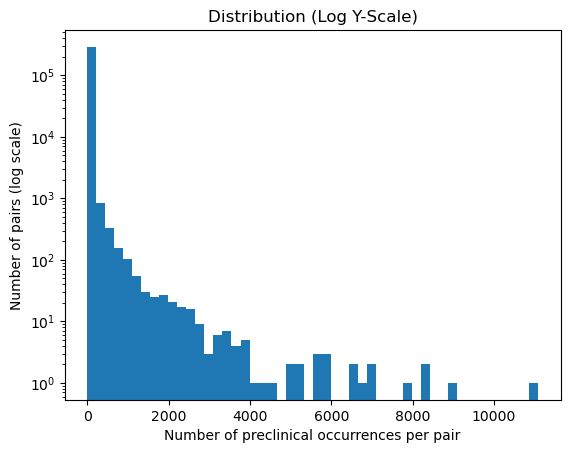

In [69]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(preclin_counts.values, bins=50)
plt.yscale("log")
plt.xlabel("Number of preclinical occurrences per pair")
plt.ylabel("Number of pairs (log scale)")
plt.title("Distribution (Log Y-Scale)")
plt.show()